# Netflix Content Analysis: Trends, Genres, and Global Expansion

Goal:
Analyze Netflix's content library and identify trends in content production, genres, and geographic distribution.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Looking for null values 

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# Cleaning up the missing values

df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])  # Using .mode() since rating is categorical 
df['date_added'] = df['date_added'].fillna('Unknown')

# Remove duplicates

df.drop_duplicates(inplace=True)
df= df[df['country'] != 'Unknown']

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7976 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7976 non-null   object
 1   type          7976 non-null   object
 2   title         7976 non-null   object
 3   director      7976 non-null   object
 4   cast          7976 non-null   object
 5   country       7976 non-null   object
 6   date_added    7976 non-null   object
 7   release_year  7976 non-null   int64 
 8   rating        7976 non-null   object
 9   duration      7973 non-null   object
 10  listed_in     7976 non-null   object
 11  description   7976 non-null   object
dtypes: int64(1), object(11)
memory usage: 810.1+ KB


## 1. Does the Netflix Database contain more Movies or TV Shows? 

In [5]:
counts = df['type'].value_counts()
counts


type
Movie      5691
TV Show    2285
Name: count, dtype: int64

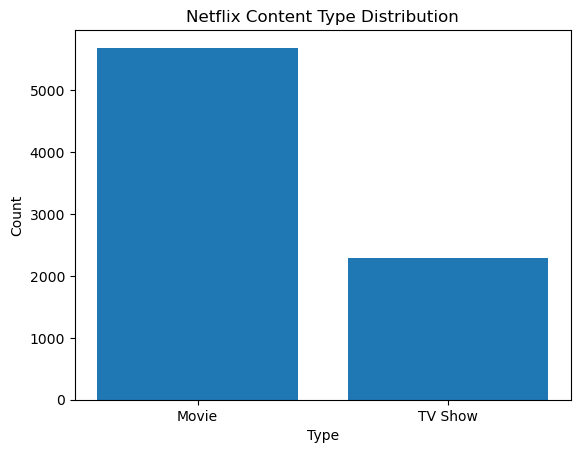

In [6]:
plt.bar(counts.index, counts.values)
plt.title("Netflix Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Movies make up the majority of Netflix’s catalog, significantly outnumbering TV shows. This suggests that Netflix’s content library is still more film-heavy, despite the growing popularity of serialized streaming content

In [7]:
df['date_added']

0       September 25, 2021
1       September 24, 2021
4       September 24, 2021
7       September 24, 2021
8       September 24, 2021
               ...        
8801         March 9, 2016
8802     November 20, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 7976, dtype: object

## 2. How many titles are added each year?

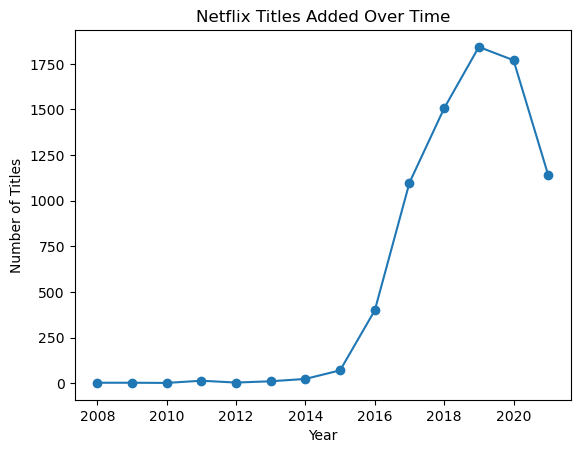

In [8]:
# convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# extract year
df['year_added'] = df['date_added'].dt.year

# count titles per year
year_counts = df['year_added'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Netflix Titles Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

The line chart shows a sharp increase in Netflix content additions starting around 2016, followed by steady growth until approximately 2019. After this peak, the number of new titles added per year shows a declining trend. This suggests that Netflix experienced a rapid expansion phase before stabilizing its content growth in recent years.

## 3. Top 10 countries producing Netflix content

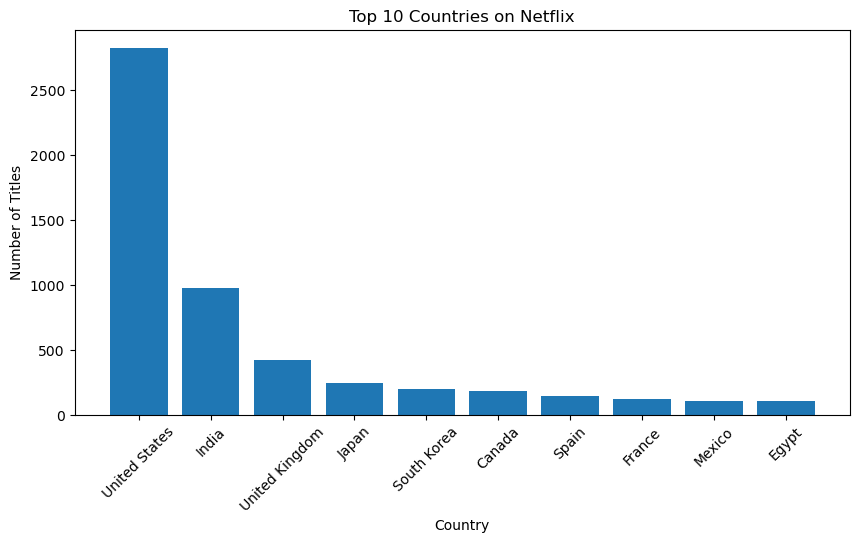

In [9]:
country_counts = df['country'].value_counts()
top10 = country_counts.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

The United States is the dominant producer of Netflix content, followed by India and the United Kingdom, indicating that Netflix’s catalog is still heavily driven by US-based productions despite increasing international diversification

## 4. Most common genres

In [ ]:
# Split the genres

genres = df['listed_in'].str.split(', ').explode()
genres  

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
4         International TV Shows
                  ...           
8805    Children & Family Movies
8805                    Comedies
8806                      Dramas
8806        International Movies
8806            Music & Musicals
Name: listed_in, Length: 17601, dtype: object

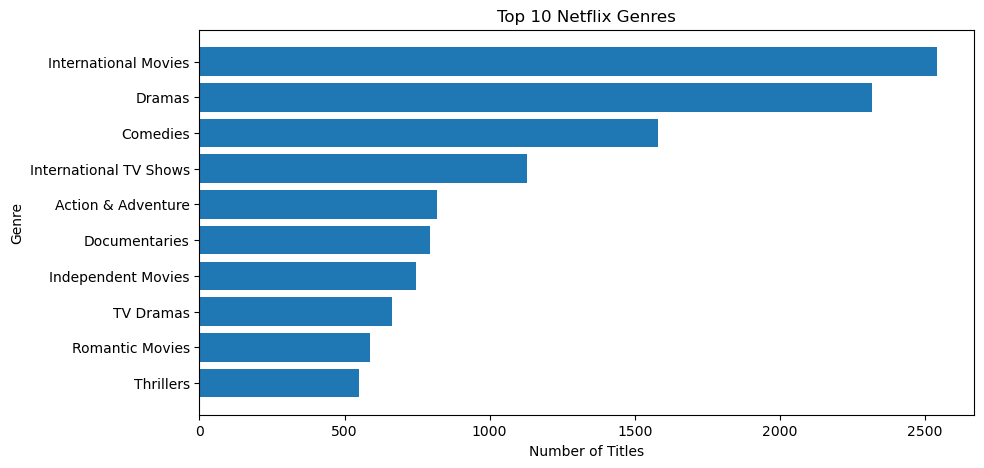

In [17]:
genre_counts = genres.value_counts()
top10 = genre_counts.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10.index, top10.values)
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.show()

The most common genres in the dataset are International Movies, Dramas, and Comedies, indicating that Netflix’s content library is heavily focused on globally appealing and narrative-driven content.

## 5.Movie duration distribution

In [30]:
movies = df[df['type'] == 'Movie']
movies['duration_clean'] = movies['duration'].str.replace(' min', '').astype(float)

/var/folders/lv/8qdk3m3j7j7g3ctkxxy66v1h0000gn/T/ipykernel_18268/418726016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_clean'] = movies['duration'].str.replace(' min', '').astype(float)


In [ ]:
movies['duration_clean'].mean()


np.float64(90.0)

In [37]:
movies['duration_clean'].mode()[0]

np.float64(90.0)

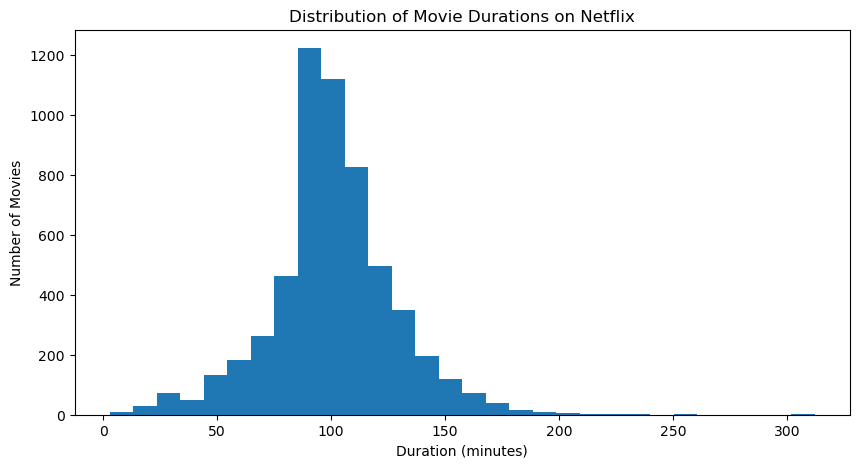

In [38]:
plt.figure(figsize=(10,5))
plt.hist(movies['duration_clean'], bins=30)
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()

In [40]:
bins = range(0, 250, 10)

movies['duration_bin'] = pd.cut(movies['duration_clean'], bins)

clustered = movies['duration_bin'].value_counts().sort_index()

clustered
clustered.idxmax()

/var/folders/lv/8qdk3m3j7j7g3ctkxxy66v1h0000gn/T/ipykernel_18268/3152505646.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_bin'] = pd.cut(movies['duration_clean'], bins)


Interval(90, 100, closed='right')

The average Netflix movie duration is around 90 minutes, with most movies clustered around 90–100 minutes, indicating a standard feature-length format dominates the platform.The overall distribution is right-skewed with fewer very long movies.